# Training the PPO Agent

This notebook trains a [Proximal Policy Optimization (PPO)](https://arxiv.org/abs/1707.06347) agent on `SimpleHVACEnv` using [Stable-Baselines3](https://stable-baselines3.readthedocs.io/).

## Why PPO?

PPO is a policy gradient algorithm that:
- **Clips the policy update** to prevent catastrophic steps — more stable than vanilla policy gradient
- **Works well with discrete actions** — our 3-action space (cool/off/heat) is a natural fit
- **Sample-efficient for low-dimensional environments** — our 2D observation converges quickly
- **Well-supported in SB3** — battle-tested implementation with good defaults

## Training setup

| Hyperparameter | Value | Note |
|---|---|---|
| Algorithm | PPO | SB3 default config |
| Policy | MlpPolicy | 2-layer MLP, 64 units each |
| Total timesteps | 20,000 | Enough to converge on this simple env |
| Learning rate | 3e-4 | SB3 default |
| Batch size | 2,048 | SB3 default n_steps |

We use SB3 defaults as a first pass. For a real project, hyperparameter tuning (e.g., with Optuna) would come next.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback

from rl_hvac_control.env.hvac_env import SimpleHVACEnv

## 1. Validate the environment

`check_env` runs SB3's built-in sanity checks: correct observation/action shapes, dtype compatibility, `reset()` and `step()` return signatures. If this passes silently, the env is SB3-compatible.

In [2]:
env = SimpleHVACEnv()
check_env(env)
print("Environment check passed.")

Environment check passed.


## 2. Set up a reward-tracking callback

SB3 logs training metrics internally, but doesn't expose per-episode reward easily. This lightweight callback records mean episode reward every `log_freq` steps so we can plot a learning curve.

In [3]:
class RewardLogCallback(BaseCallback):
    """Records mean episode reward at regular intervals."""

    def __init__(self, log_freq=1000, verbose=0):
        super().__init__(verbose)
        self.log_freq = log_freq
        self.timesteps = []
        self.mean_rewards = []
        self._episode_rewards = []
        self._episode_reward = 0.0

    def _on_step(self):
        self._episode_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self._episode_rewards.append(self._episode_reward)
            self._episode_reward = 0.0

        if self.num_timesteps % self.log_freq == 0 and self._episode_rewards:
            self.timesteps.append(self.num_timesteps)
            self.mean_rewards.append(np.mean(self._episode_rewards[-10:]))

        return True

## 3. Train

Training takes ~2–3 minutes on CPU. The SB3 verbose output shows KL divergence, clip fraction, and value loss — all should decrease as training progresses, indicating the policy is improving.

In [4]:
reward_callback = RewardLogCallback(log_freq=1000)

model = PPO(
    "MlpPolicy",
    env,
    verbose=1
)

model.learn(total_timesteps=20_000, callback=reward_callback)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -1.74e+03 |
| time/              |           |
|    fps             | 794       |
|    iterations      | 1         |
|    time_elapsed    | 2         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 200         |
|    ep_rew_mean          | -1.6e+03    |
| time/                   |             |
|    fps                  | 365         |
|    iterations           | 2           |
|    time_elapsed         | 11          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013098542 |
|    clip_fraction        | 0.222       |
|    clip_range           | 0.2         |
|    entro

## 4. Save the model

The trained model is saved to `results/ppo_hvac.zip` so `results_analysis.ipynb` can load it without re-training.

In [5]:
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)
model.save(results_dir / "ppo_hvac")
print(f"Model saved to {results_dir / 'ppo_hvac.zip'}")

Model saved to ..\results\ppo_hvac.zip


## 5. Learning curve

This is the key diagnostic plot: **mean episode reward vs. training timesteps**.

A well-trained agent should show a clear upward trend. If the curve plateaus early, the agent has converged (possibly to a local optimum). If it's still rising at 20,000 steps, more training would help.

The dashed lines mark the rule-based (~−194) and PID (~−131) baselines from `controller_comparison.ipynb`. A PPO agent that beats both baselines has learned a genuinely better policy.

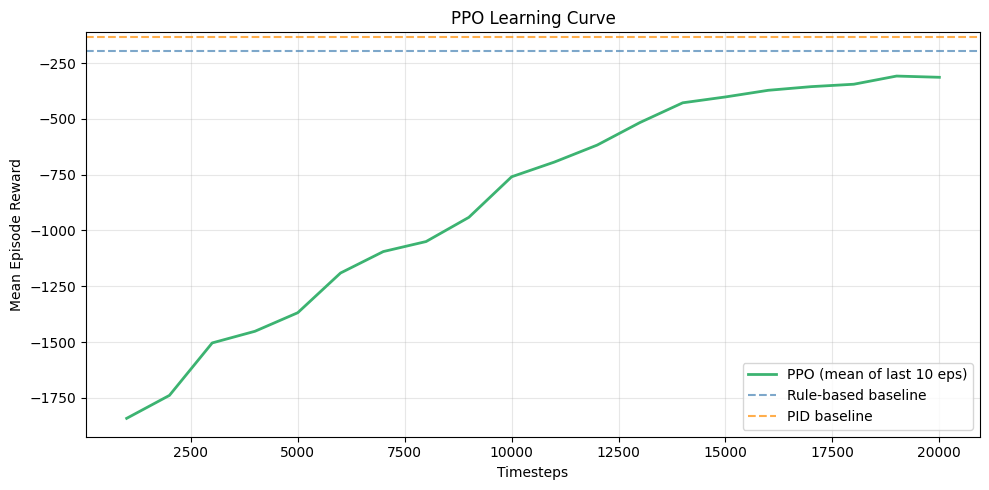

In [6]:
if reward_callback.timesteps:
    plt.figure(figsize=(10, 5))
    plt.plot(reward_callback.timesteps, reward_callback.mean_rewards,
             color='mediumseagreen', linewidth=2, label='PPO (mean of last 10 eps)')
    plt.axhline(-194, linestyle='--', color='steelblue', alpha=0.7, label='Rule-based baseline')
    plt.axhline(-131, linestyle='--', color='darkorange', alpha=0.7, label='PID baseline')
    plt.xlabel("Timesteps")
    plt.ylabel("Mean Episode Reward")
    plt.title("PPO Learning Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No reward data recorded — check callback setup.")

## 6. Evaluate the trained agent

Run one full episode with the trained policy (deterministic = no exploration noise) and plot the temperature trace.

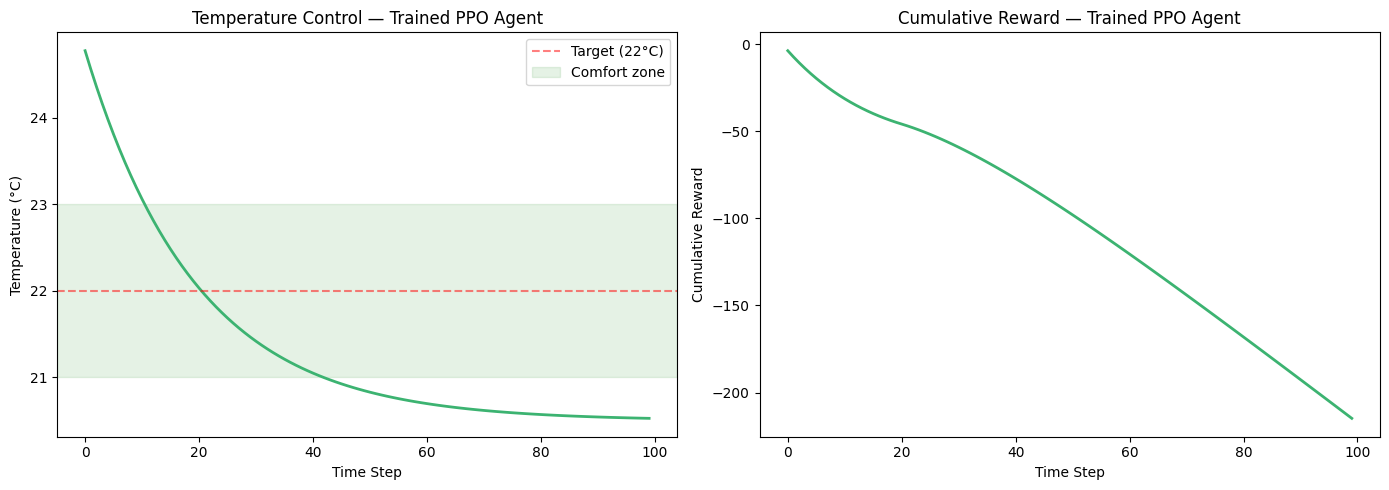

Total reward (PPO): -214.77
Steps in comfort zone [21-23°C]: 31/100


In [7]:
temps = []
rewards = []

obs, _ = env.reset()

for _ in range(100):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = env.step(action)
    temps.append(obs[0])
    rewards.append(reward)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(temps, color='mediumseagreen', linewidth=2)
axes[0].axhline(22, linestyle='--', color='red', alpha=0.5, label='Target (22°C)')
axes[0].axhspan(21, 23, alpha=0.1, color='green', label='Comfort zone')
axes[0].set_title("Temperature Control — Trained PPO Agent")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()

axes[1].plot(np.cumsum(rewards), color='mediumseagreen', linewidth=2)
axes[1].set_title("Cumulative Reward — Trained PPO Agent")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Cumulative Reward")

plt.tight_layout()
plt.show()

print(f"Total reward (PPO): {sum(rewards):.2f}")
print(f"Steps in comfort zone [21-23°C]: {sum(21 <= t <= 23 for t in temps)}/100")

## Summary

The PPO agent is trained and saved. Key things to check:
- Does the learning curve show upward progress? (It should)
- Does the trained agent exceed the PID baseline reward of ~−131?
- Does it spend more time in the comfort zone than the classical controllers?

**Next**: `results_analysis.ipynb` — full three-way comparison with metrics.